# XAI Analysis: Baseline ResNet18 vs DeMemte

Este notebook desentraña por qué DeMemte generaliza mejor en CIFAR-10 (k-NN) pero cae más con ruido en Flowers102.

Incluye:
- Señal de memoria y error de reconstrucción (clean vs noisy)
- Shift de features (clean vs noisy)
- Análisis de compuertas sparse
- Grad-CAM para foco espacial
- Prototipo arquitectónico `DeMemteV2` para robustez al ruido

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, hard_threshold: float = 0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)

        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))

        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 2 or x.shape[1] != self.in_features:
            raise ValueError(f'x debe ser (B, {self.in_features})')

        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft

        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    @torch.no_grad()
    def gate_soft(self) -> torch.Tensor:
        return torch.sigmoid(self.logits / self.temperature)

    @torch.no_grad()
    def hard_mask(self) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        return (gate_soft > self.hard_threshold)

class VAE(nn.Module):
    def __init__(self, input_dim, output_dim, latent_dim=128):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.fc1 = LearnedSparseLinear(input_dim, 400)
        self.fc21 = LearnedSparseLinear(400, latent_dim)
        self.fc22 = LearnedSparseLinear(400, latent_dim)
        self.fc3 = LearnedSparseLinear(latent_dim, 400)
        self.fc4 = LearnedSparseLinear(400, output_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        x_rec = self.decode(z)
        return x_rec, mu, logvar

class DeMemte(nn.Module):
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vae = vae

        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            raw_features = self.backbone(x)
        features = self.feat_norm(raw_features)

        x_rec, mu, logvar = self.vae(features)
        recon_diff = (features - x_rec) ** 2
        recon_loss_per_sample = torch.mean(recon_diff, dim=1, keepdim=True)

        gamma = F.softplus(self.signal_gamma)
        signal = torch.exp(-recon_loss_per_sample * gamma)

        enhanced_features = features + (self.memory_scale * signal * x_rec)
        logits = self.classifier(enhanced_features)

        return logits, x_rec, mu, logvar, features

    def train(self, mode: bool = True):
        super().train(mode)
        self.backbone.eval()
        return self

class DeMemteInspectable(DeMemte):
    def forward_with_details(self, x):
        with torch.no_grad():
            raw_features = self.backbone(x)
        features = self.feat_norm(raw_features)

        x_rec, mu, logvar = self.vae(features)
        recon_diff = (features - x_rec) ** 2
        recon_loss = torch.mean(recon_diff, dim=1, keepdim=True)

        gamma = F.softplus(self.signal_gamma)
        signal = torch.exp(-recon_loss * gamma)

        enhanced_features = features + (self.memory_scale * signal * x_rec)
        logits = self.classifier(enhanced_features)

        return {
            'logits': logits,
            'x_rec': x_rec,
            'mu': mu,
            'logvar': logvar,
            'features': features,
            'enhanced_features': enhanced_features,
            'recon_loss': recon_loss,
            'signal': signal,
            'gamma': gamma.detach().cpu().item()
        }

def get_resnet_baseline(num_classes=102):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_dememte_model(num_classes=102, inspectable=True):
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base_model.children())[:-1], nn.Flatten())
    embedding_dim = base_model.fc.in_features
    vae = VAE(input_dim=embedding_dim, output_dim=embedding_dim, latent_dim=128)

    if inspectable:
        model = DeMemteInspectable(backbone, vae, embedding_dim, num_classes)
    else:
        model = DeMemte(backbone, vae, embedding_dim, num_classes)
    return model

def unwrap_state_dict(ckpt):
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        return ckpt['model_state_dict']
    return ckpt

In [3]:
num_classes = 102
batch_size = 64
data_dir = '../data'
ckpt_dir = '../out'

transform_clean = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

def add_gaussian_noise(x, std=0.5):
    return x + torch.randn_like(x) * std

flowers_test = torchvision.datasets.Flowers102(root=data_dir, split='test', download=True, transform=transform_clean)
test_loader = DataLoader(flowers_test, batch_size=batch_size, shuffle=False, num_workers=2)

# Subset para análisis XAI rápido
subset_n = 800
indices = list(range(min(subset_n, len(flowers_test))))
flowers_subset = Subset(flowers_test, indices)
subset_loader = DataLoader(flowers_subset, batch_size=64, shuffle=False, num_workers=2)

print(f'Flowers test size: {len(flowers_test)}')
print(f'XAI subset size: {len(flowers_subset)}')

Flowers test size: 6149
XAI subset size: 800


In [4]:
baseline_model = get_resnet_baseline(num_classes).to(device)
dememte_model = get_dememte_model(num_classes, inspectable=True).to(device)

baseline_ckpt = torch.load(os.path.join(ckpt_dir, 'baseline_resnet18_flowers102.pth'), map_location=device)
dememte_ckpt = torch.load(os.path.join(ckpt_dir, 'dememte_optimized_flowers102.pth'), map_location=device)

baseline_model.load_state_dict(unwrap_state_dict(baseline_ckpt))
dememte_model.load_state_dict(unwrap_state_dict(dememte_ckpt))

baseline_model.eval()
dememte_model.eval()
print('Models loaded successfully.')

Models loaded successfully.


In [5]:
@torch.no_grad()
def evaluate_clean_and_noisy(model, loader, is_dememte=False, noise_std=0.5):
    clean_correct, noisy_correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_noisy = add_gaussian_noise(x, std=noise_std)

        if is_dememte:
            clean_logits = model.forward_with_details(x)['logits']
            noisy_logits = model.forward_with_details(x_noisy)['logits']
        else:
            clean_logits = model(x)
            noisy_logits = model(x_noisy)

        clean_correct += (clean_logits.argmax(1) == y).sum().item()
        noisy_correct += (noisy_logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return 100 * clean_correct / total, 100 * noisy_correct / total

base_clean, base_noisy = evaluate_clean_and_noisy(baseline_model, test_loader, is_dememte=False, noise_std=0.5)
dem_clean, dem_noisy = evaluate_clean_and_noisy(dememte_model, test_loader, is_dememte=True, noise_std=0.5)

print('--- Quick sanity metrics ---')
print(f'Baseline clean: {base_clean:.2f}% | noisy: {base_noisy:.2f}%')
print(f'DeMemte  clean: {dem_clean:.2f}% | noisy: {dem_noisy:.2f}%')

--- Quick sanity metrics ---
Baseline clean: 80.78% | noisy: 35.84%
DeMemte  clean: 79.25% | noisy: 34.25%


## 1) Memory Signal & Reconstruction Loss (XAI interno)

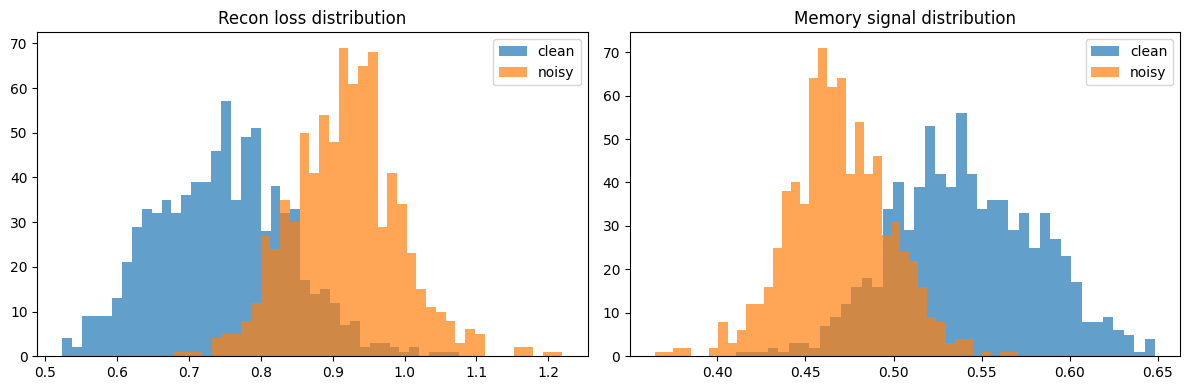

Mean recon loss clean/noisy: 0.7465 / 0.9177
Mean signal    clean/noisy: 0.5408 / 0.4689


In [6]:
@torch.no_grad()
def collect_dememte_internal_stats(model, loader, noise_std=0.5):
    clean_recon, noisy_recon = [], []
    clean_signal, noisy_signal = [], []

    for x, _ in loader:
        x = x.to(device)
        x_noisy = add_gaussian_noise(x, std=noise_std)

        d_clean = model.forward_with_details(x)
        d_noisy = model.forward_with_details(x_noisy)

        clean_recon.append(d_clean['recon_loss'].squeeze(1).cpu().numpy())
        noisy_recon.append(d_noisy['recon_loss'].squeeze(1).cpu().numpy())
        clean_signal.append(d_clean['signal'].squeeze(1).cpu().numpy())
        noisy_signal.append(d_noisy['signal'].squeeze(1).cpu().numpy())

    return {
        'clean_recon': np.concatenate(clean_recon),
        'noisy_recon': np.concatenate(noisy_recon),
        'clean_signal': np.concatenate(clean_signal),
        'noisy_signal': np.concatenate(noisy_signal),
    }

stats = collect_dememte_internal_stats(dememte_model, subset_loader, noise_std=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(stats['clean_recon'], bins=40, alpha=0.7, label='clean')
axes[0].hist(stats['noisy_recon'], bins=40, alpha=0.7, label='noisy')
axes[0].set_title('Recon loss distribution')
axes[0].legend()

axes[1].hist(stats['clean_signal'], bins=40, alpha=0.7, label='clean')
axes[1].hist(stats['noisy_signal'], bins=40, alpha=0.7, label='noisy')
axes[1].set_title('Memory signal distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Mean recon loss clean/noisy: {stats['clean_recon'].mean():.4f} / {stats['noisy_recon'].mean():.4f}")
print(f"Mean signal    clean/noisy: {stats['clean_signal'].mean():.4f} / {stats['noisy_signal'].mean():.4f}")

## 2) Feature Shift: ¿La memoria corrige o amplifica el ruido?

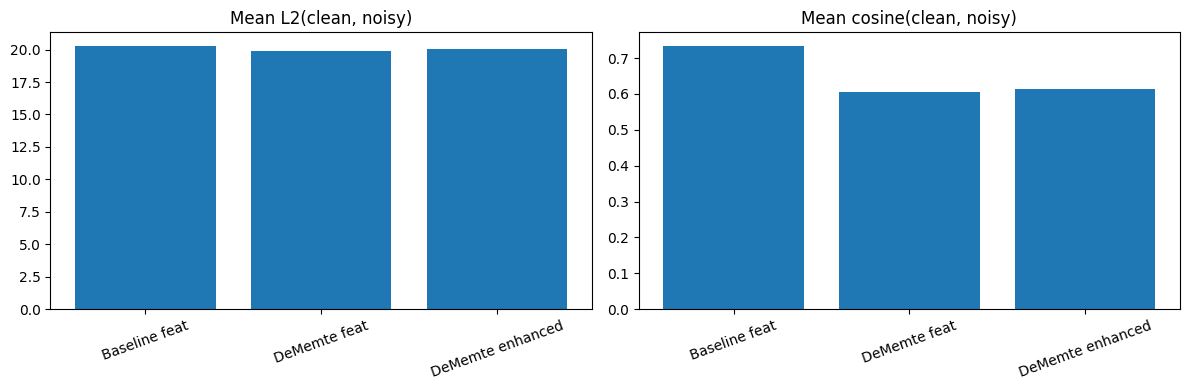

Interpretación rápida:
- Menor L2 y mayor coseno => más estable ante ruido.
- Compara DeMemte feature vs DeMemte enhanced para ver si la memoria ayuda o empeora.


In [7]:
@torch.no_grad()
def baseline_features(model, x):
    backbone = nn.Sequential(*list(model.children())[:-1], nn.Flatten()).to(device)
    return backbone(x)

@torch.no_grad()
def collect_shift_stats(baseline, dememte, loader, noise_std=0.5):
    l2_base, l2_dem_feat, l2_dem_enh = [], [], []
    cos_base, cos_dem_feat, cos_dem_enh = [], [], []

    for x, _ in loader:
        x = x.to(device)
        x_noisy = add_gaussian_noise(x, std=noise_std)

        b_clean = baseline_features(baseline, x)
        b_noisy = baseline_features(baseline, x_noisy)

        d_clean = dememte.forward_with_details(x)
        d_noisy = dememte.forward_with_details(x_noisy)

        df_c, df_n = d_clean['features'], d_noisy['features']
        de_c, de_n = d_clean['enhanced_features'], d_noisy['enhanced_features']

        l2_base.extend(torch.norm(b_clean - b_noisy, dim=1).cpu().numpy())
        l2_dem_feat.extend(torch.norm(df_c - df_n, dim=1).cpu().numpy())
        l2_dem_enh.extend(torch.norm(de_c - de_n, dim=1).cpu().numpy())

        b_c = b_clean.cpu().numpy(); b_n = b_noisy.cpu().numpy()
        dfc = df_c.cpu().numpy(); dfn = df_n.cpu().numpy()
        dec = de_c.cpu().numpy(); den = de_n.cpu().numpy()

        cos_base.extend(np.diag(cosine_similarity(b_c, b_n)))
        cos_dem_feat.extend(np.diag(cosine_similarity(dfc, dfn)))
        cos_dem_enh.extend(np.diag(cosine_similarity(dec, den)))

    return {
        'l2_base': np.array(l2_base),
        'l2_dem_feat': np.array(l2_dem_feat),
        'l2_dem_enh': np.array(l2_dem_enh),
        'cos_base': np.array(cos_base),
        'cos_dem_feat': np.array(cos_dem_feat),
        'cos_dem_enh': np.array(cos_dem_enh),
    }

shift = collect_shift_stats(baseline_model, dememte_model, subset_loader, noise_std=0.5)

labels = ['Baseline feat', 'DeMemte feat', 'DeMemte enhanced']
l2_means = [shift['l2_base'].mean(), shift['l2_dem_feat'].mean(), shift['l2_dem_enh'].mean()]
cos_means = [shift['cos_base'].mean(), shift['cos_dem_feat'].mean(), shift['cos_dem_enh'].mean()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, l2_means)
axes[0].set_title('Mean L2(clean, noisy)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, cos_means)
axes[1].set_title('Mean cosine(clean, noisy)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Interpretación rápida:')
print('- Menor L2 y mayor coseno => más estable ante ruido.')
print('- Compara DeMemte feature vs DeMemte enhanced para ver si la memoria ayuda o empeora.')

## 3) Sparse gates: sensibilidad de la capa clasificadora

Gate soft mean: 0.5050
Gate soft > 0.5 ratio: 0.4894


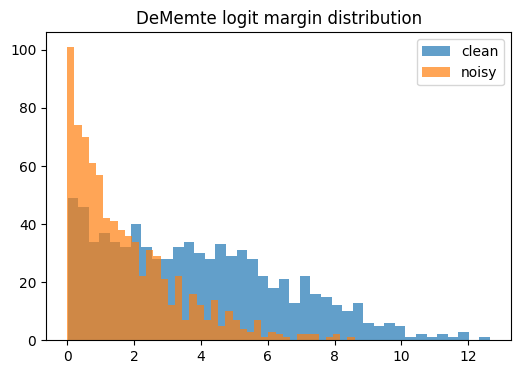

Logit margin mean clean/noisy: 3.8577 / 1.7215


In [8]:
@torch.no_grad()
def classifier_margin(logits):
    top2 = torch.topk(logits, k=2, dim=1).values
    return (top2[:, 0] - top2[:, 1]).cpu().numpy()

gsoft = dememte_model.classifier.gate_soft().cpu().numpy()
print(f'Gate soft mean: {gsoft.mean():.4f}')
print(f'Gate soft > 0.5 ratio: {(gsoft > 0.5).mean():.4f}')

clean_margins, noisy_margins = [], []
for x, _ in subset_loader:
    x = x.to(device)
    x_noisy = add_gaussian_noise(x, std=0.5)

    clean_logits = dememte_model.forward_with_details(x)['logits']
    noisy_logits = dememte_model.forward_with_details(x_noisy)['logits']

    clean_margins.extend(classifier_margin(clean_logits))
    noisy_margins.extend(classifier_margin(noisy_logits))

clean_margins = np.array(clean_margins)
noisy_margins = np.array(noisy_margins)

plt.figure(figsize=(6, 4))
plt.hist(clean_margins, bins=40, alpha=0.7, label='clean')
plt.hist(noisy_margins, bins=40, alpha=0.7, label='noisy')
plt.title('DeMemte logit margin distribution')
plt.legend()
plt.show()

print(f'Logit margin mean clean/noisy: {clean_margins.mean():.4f} / {noisy_margins.mean():.4f}')

## 4) Grad-CAM (foco espacial clean vs noisy)

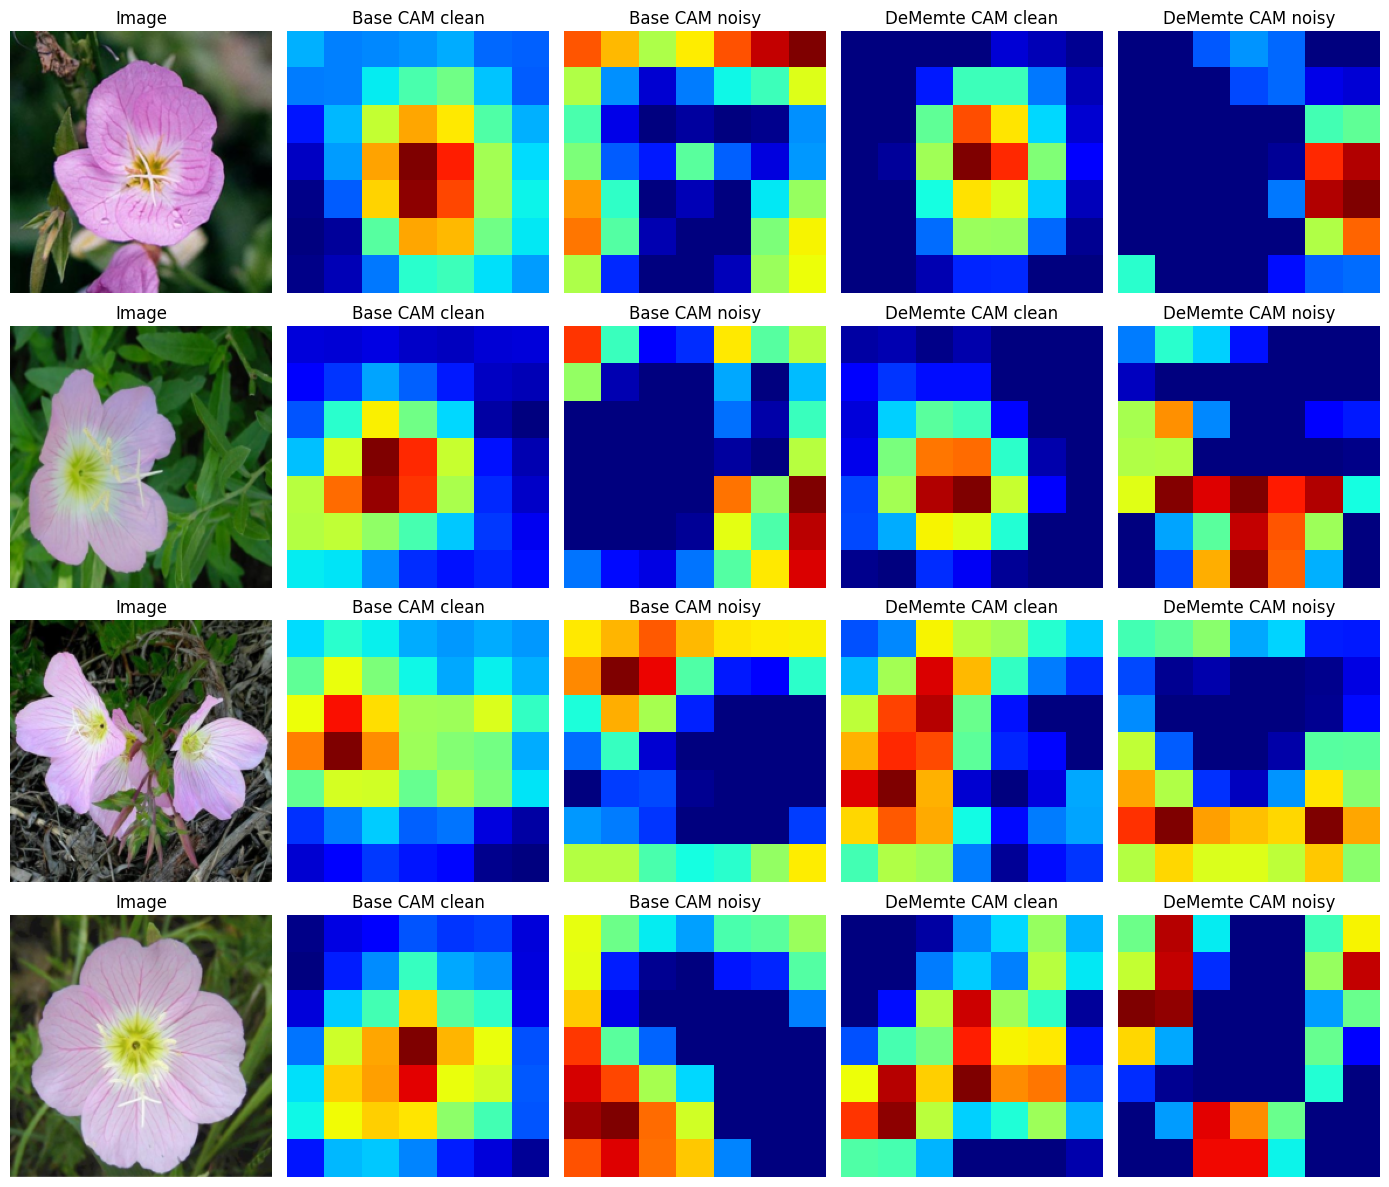

In [10]:
class SimpleGradCAM:
    def __init__(self, model, target_layer, forward_fn):
        self.model = model
        self.target_layer = target_layer
        self.forward_fn = forward_fn
        self.activations = None
        self.gradients = None

        self._fh = target_layer.register_forward_hook(self._forward_hook)
        self._bh = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.forward_fn(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1)

        batch_idx = torch.arange(logits.size(0), device=logits.device)
        score = logits[batch_idx, class_idx].sum()
        score.backward(retain_graph=False)

        grads = self.gradients
        acts = self.activations

        if grads is None or acts is None:
            raise RuntimeError("Grad-CAM no pudo capturar gradientes/activaciones. Verifica que el forward sea diferenciable y el target layer sea correcto.")

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam_min = cam.amin(dim=(2, 3), keepdim=True)
        cam_max = cam.amax(dim=(2, 3), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        return cam

    def close(self):
        self._fh.remove()
        self._bh.remove()

def forward_baseline(x):
    return baseline_model(x)

def forward_dememte_for_cam(x):
    # Forward diferenciable para Grad-CAM (sin torch.no_grad en backbone)
    raw_features = dememte_model.backbone(x)
    features = dememte_model.feat_norm(raw_features)

    x_rec, _, _ = dememte_model.vae(features)
    recon_diff = (features - x_rec) ** 2
    recon_loss = torch.mean(recon_diff, dim=1, keepdim=True)

    gamma = F.softplus(dememte_model.signal_gamma)
    signal = torch.exp(-recon_loss * gamma)

    enhanced_features = features + (dememte_model.memory_scale * signal * x_rec)
    logits = dememte_model.classifier(enhanced_features)
    return logits

baseline_target_layer = baseline_model.layer4[-1].conv2
dememte_target_layer = dememte_model.backbone[7][-1].conv2

cam_baseline = SimpleGradCAM(baseline_model, baseline_target_layer, forward_baseline)
cam_dememte = SimpleGradCAM(dememte_model, dememte_target_layer, forward_dememte_for_cam)

x_batch, y_batch = next(iter(subset_loader))
x_batch = x_batch[:4].to(device)
x_noisy_batch = add_gaussian_noise(x_batch, std=0.5)

with torch.enable_grad():
    clean_cam_b = cam_baseline.generate(x_batch).detach().cpu()
    noisy_cam_b = cam_baseline.generate(x_noisy_batch).detach().cpu()

    clean_cam_d = cam_dememte.generate(x_batch).detach().cpu()
    noisy_cam_d = cam_dememte.generate(x_noisy_batch).detach().cpu()

def denorm_img(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1)

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
for i in range(4):
    img = denorm_img(x_batch[i])
    axes[i, 0].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[i, 0].set_title('Image')

    axes[i, 1].imshow(clean_cam_b[i, 0], cmap='jet')
    axes[i, 1].set_title('Base CAM clean')

    axes[i, 2].imshow(noisy_cam_b[i, 0], cmap='jet')
    axes[i, 2].set_title('Base CAM noisy')

    axes[i, 3].imshow(clean_cam_d[i, 0], cmap='jet')
    axes[i, 3].set_title('DeMemte CAM clean')

    axes[i, 4].imshow(noisy_cam_d[i, 0], cmap='jet')
    axes[i, 4].set_title('DeMemte CAM noisy')

    for j in range(5):
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

cam_baseline.close()
cam_dememte.close()